In [21]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 1. Grötzsch Graph
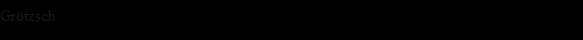

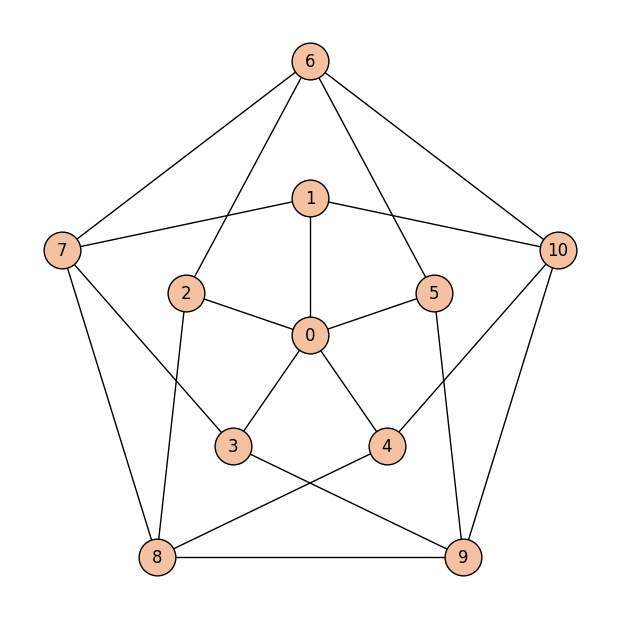

In [22]:
import math

G_first = nx.Graph()
edges = [
    # Center connections
    (0, 1), (0, 2), (0, 3), (0, 4), (0, 5),
    # Outer pentagon
    (6, 7), (7, 8), (8, 9), (9, 10), (10, 6),
    # Spokes between outer and inner
    (6, 2), (6, 5), (7, 1), (7, 3), (8, 2), (8, 4), (9, 3), (9, 5), (10, 1), (10, 4)
]
G_first.add_edges_from(edges)

pos = {0: (0.0, 0.0)}

inner_radius = 1.5
for i, node in enumerate([1, 2, 3, 4, 5]):
    angle = 2 * math.pi * i / 5 + math.pi / 2
    pos[node] = (
        inner_radius * math.cos(angle),
        inner_radius * math.sin(angle)
    )

outer_radius = 3
for i, node in enumerate([6, 7, 8, 9, 10]):
    angle = 2 * math.pi * i / 5 + math.pi / 2
    pos[node] = (
        outer_radius * math.cos(angle),
        outer_radius * math.sin(angle)
    )

plt.figure(figsize=(6, 6))
nx.draw(
    G_first, pos,
    with_labels=True,
    node_size=700,
    node_color='#f4c2a1',
    edgecolors='black'
)
plt.show()

In [23]:
print('Node Count:', len(nx.nodes(G_first)))
print('Edge Count:', len(nx.edges(G_first)))
print('Radius:', nx.radius(G_first))
print('Girth:', nx.girth(G_first))
print('Diameter:', nx.diameter(G_first))

Node Count: 11
Edge Count: 20
Radius: 2
Girth: 4
Diameter: 2


## 2. Adjacency Matrix to Adjacency List/Incidence Matrix
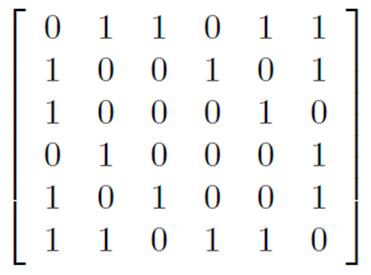
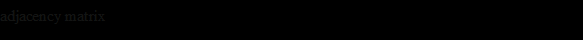

In [24]:
adjacency_matrix = [
    [0, 1, 1, 0, 1, 1],
    [1, 0, 0, 1, 0, 1],
    [1, 0, 0, 0, 1, 0],
    [0, 1, 0, 0, 0, 1],
    [1, 0, 1, 0, 0, 1],
    [1, 1, 0, 1, 1, 0]
]
G_second = nx.from_numpy_array(np.array(adjacency_matrix))
for i, (u, v) in enumerate(G_second.edges()):
    G_second[u][v]['label'] = f'e{i}'

In [25]:
for adj_node in nx.generate_adjlist(G_second, delimiter='->'):
    print(adj_node)

0->1->2->4->5
1->3->5
2->4
3->5
4->5
5


In [26]:
G_2_inc_mat = pd.DataFrame(nx.incidence_matrix(G_second).todense(), dtype=int)
G_2_inc_mat.columns = nx.get_edge_attributes(G_second, 'label').values()
G_2_inc_mat

,e0,e1,e2,e3,e4,e5,e6,e7,e8
0,1,1,1,1,0,0,0,0,0
1,1,0,0,0,1,1,0,0,0
2,0,1,0,0,0,0,1,0,0
3,0,0,0,0,1,0,0,1,0
4,0,0,1,0,0,0,1,0,1
5,0,0,0,1,0,1,0,1,1


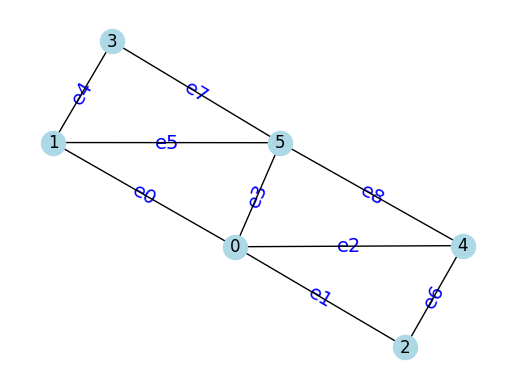

In [27]:
edge_labels = nx.get_edge_attributes(G_second, 'label')
G_second_pos = nx.spring_layout(G_second)
nx.draw_networkx_edge_labels(
    G_second,
    pos=G_second_pos,
    edge_labels=edge_labels,
    font_color='blue',
    font_size=14
)
nx.draw(
    G_second,
    with_labels=True,
    pos=G_second_pos,
    node_color='lightblue'
)

## 3. Modify the following Python code to visualize the graph above.

In [28]:
G_third = nx.Graph()
edges = [
    ('A', 'C'), ('A', 'F'), ('F', 'H'), ('C', 'D'),
    ('C', 'F'), ('C', 'H'), ('D', 'H'), ('D', 'E'),
    ('D', 'B'), ('E', 'F'), ('E', 'B'), ('E', 'H')
]
for edge in edges:
    G_third.add_edge(*edge)

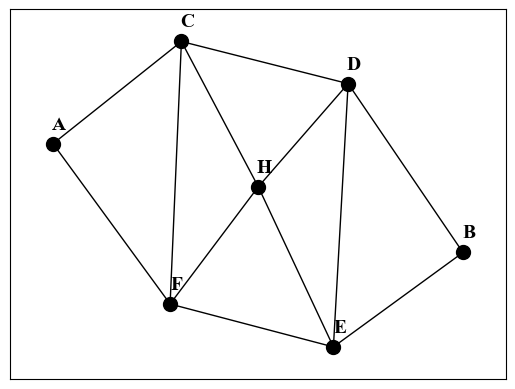

In [29]:
np.random.seed(19)
graph_pos = nx.spring_layout(G_third)
label_pos = {node: [pos[0] + 0.03, pos[1] + 0.04]
             for node, pos in graph_pos.items()}
nx.draw_networkx(
    G_third, pos=graph_pos, node_color='black',
    node_size=100, with_labels=False)
nx.draw_networkx_labels(
    G_third, font_size=14, font_family='Times New Roman',
    font_weight='bold', pos=label_pos)
plt.show()

## 4. Calculate the following properties for the graph given in question 3.
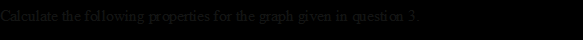

In [30]:
eccentricity = nx.eccentricity(G_third)
diameter = nx.diameter(G_third)
radius = nx.radius(G_third)
periphery = nx.periphery(G_third)
center = nx.center(G_third)

print("Eccentricity:", eccentricity)
print("Diameter:", diameter)
print("Radius:", radius)
print("Periphery:", periphery)
print("Center:", center)

Eccentricity: {'A': 3, 'C': 2, 'F': 2, 'H': 2, 'D': 2, 'E': 2, 'B': 3}
Diameter: 3
Radius: 2
Periphery: ['A', 'B']
Center: ['C', 'F', 'H', 'D', 'E']


## 5. Interactive Network Graph

In [31]:
from pyvis import network as net

G = net.Network(height='400px', notebook=True, cdn_resources='remote')
nodes = ['A', 'B', 'C', 'D', 'E', 'F', 'H']
edges = [
    ('A', 'C'), ('A', 'F'), ('F', 'H'), ('C', 'D'),
    ('C', 'F'), ('C', 'H'), ('D', 'H'), ('D', 'E'),
    ('D', 'B'), ('E', 'F'), ('E', 'B'), ('E', 'H')]
for node in nodes:
    G.add_node(node)
for edge in edges:
    G.add_edge(*edge)
G.show('mygraph.html')

mygraph.html


## 6. Run Code

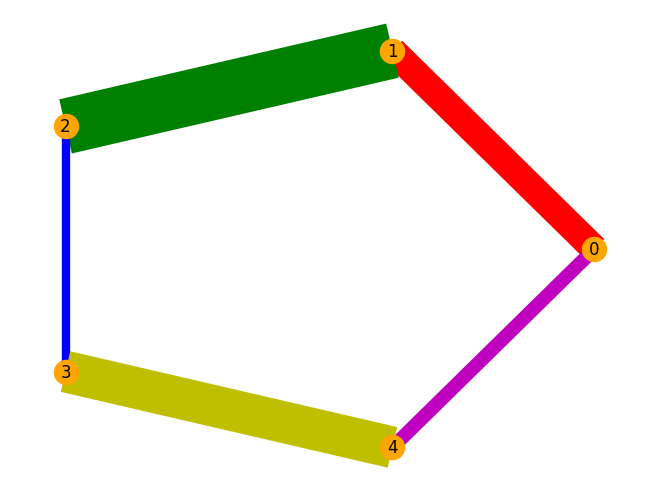

In [32]:
import networkx as nx

G = nx.Graph()
G.add_edge(0,1,color='r',weight=20)
G.add_edge(1,2,color='g',weight=40)
G.add_edge(2,3,color='b',weight=6)
G.add_edge(3,4,color='y',weight=30)
G.add_edge(4,0,color='m',weight=10)

colors = nx.get_edge_attributes(G,'color').values()
weights = nx.get_edge_attributes(G,'weight').values()

pos = nx.circular_layout(G)
nx.draw(G, pos,
        edge_color=colors,
        width=list(weights),
        with_labels=True,
        node_color='orange')